# Petal Data Set Logistic Regression Multiclass

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import joblib

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [2]:

iris = load_iris()


In [4]:
print(dir(iris))


['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


In [5]:
print("\nFeature Names:\n")
print(iris.feature_names)


Feature Names:

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
print("\nTarget Names:\n")
print(iris.target_names)


Target Names:

['setosa' 'versicolor' 'virginica']


In [7]:

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)


In [8]:
df['target'] = iris.target


In [9]:
print("\nDataset Preview:\n")
print(df.head())


Dataset Preview:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [10]:
X = df.drop('target', axis='columns')
y = df.target

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))


Training Samples : 120
Testing Samples : 30


In [12]:
model = LogisticRegression(max_iter=200)


In [13]:
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:

score = model.score(X_test, y_test)

print("\nModel Accuracy :", score)


Model Accuracy : 1.0


In [15]:

y_predicted = model.predict(X_test)

print("\nPredicted Values:\n")
print(y_predicted[:10])

print("\nActual Values:\n")
print(y_test[:10].values)


Predicted Values:

[1 0 2 1 1 0 1 2 1 1]

Actual Values:

[1 0 2 1 1 0 1 2 1 1]


In [16]:
sample_prediction = model.predict([
    [5.1, 3.5, 1.4, 0.2]
])

print("\nSample Prediction :", sample_prediction[0])
print("Flower Name :", iris.target_names[sample_prediction[0]])


Sample Prediction : 0
Flower Name : setosa


/home/rithik-ca/Documents/Learning and Projects/MLops_Learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [17]:
print("\nClassification Report:\n")

print(classification_report(y_test, y_predicted))



Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [18]:

cm = confusion_matrix(y_test, y_predicted)

print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


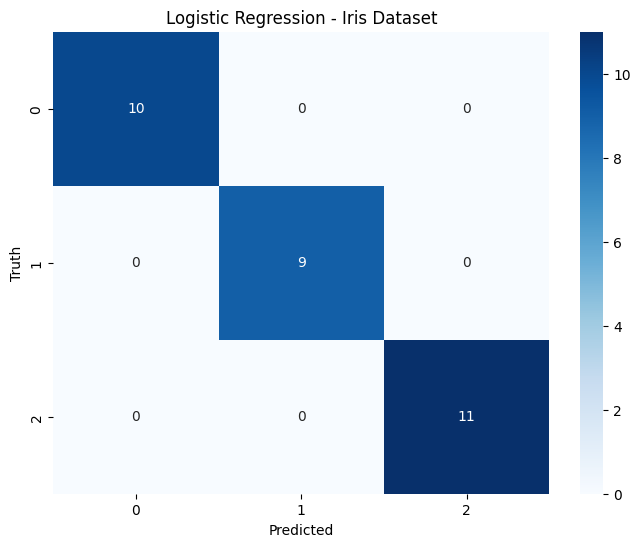

In [19]:

plt.figure(figsize=(8,6))

sn.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Logistic Regression - Iris Dataset')

plt.show()

In [20]:

joblib.dump(model, 'logistic_regression_iris_model.pkl')

print("\nModel saved successfully as logistic_regression_iris_model.pkl")



Model saved successfully as logistic_regression_iris_model.pkl


In [21]:

loaded_model = joblib.load('logistic_regression_iris_model.pkl')


In [22]:

loaded_prediction = loaded_model.predict([
    [6.2, 3.4, 5.4, 2.3]
])

print("\nPrediction from Loaded Model :", loaded_prediction[0])
print("Flower Name :", iris.target_names[loaded_prediction[0]])


Prediction from Loaded Model : 2
Flower Name : virginica


/home/rithik-ca/Documents/Learning and Projects/MLops_Learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
